# Reservoir Volume — Exploratory Data Analysis

Visualises raw volumes (m³) from `Ejercicio hidrología v2.xlsx`.

**Sections**
1. Imports & configuration
2. Load raw data
3. Data inspection
4. Violin plot — full distribution in log scale
5. Time-series per reservoir with train / test split

In [231]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

sns.set_theme(style="whitegrid", palette="tab10")
plt.rcParams.update({"figure.dpi": 120, "font.size": 10})

In [232]:
EXCEL_PATH  = "Ejercicio hidrología v2.xlsx"
SHEET_INDEX = 1        # 0-based; sheet 1 = "Datos generales"
N_TRAIN     = 3554     # first N_TRAIN rows → training set

In [233]:
import sys
sys.path.insert(0, ".")   # make src/ importable from the notebook

from src.data.preprocessing import load_raw

# ── Load raw data via the shared preprocessing entry point ────────────────────
# Any change to column extraction / cleaning in preprocessing.py is
# automatically picked up here — no duplication.
df_vol, reservoir_names = load_raw(EXCEL_PATH, sheet=SHEET_INDEX)

T_total, D = df_vol.shape
print(f"Time steps : {T_total}")
print(f"Reservoirs : {D}")
print(f"Names      : {reservoir_names}")

Time steps : 4442
Reservoirs : 23
Names      : ['AGREGADO BOGOTA', 'ALTOANCHICAYA', 'AMANI', 'BETANIA', 'CALIMA1', 'CHUZA', 'EL QUIMBO', 'ESMERALDA', 'GUAVIO', 'MIRAFLORES', 'MUNA', 'PENOL', 'PLAYAS', 'PORCE II', 'PORCE III', 'PRADO', 'PUNCHINA', 'RIOGRANDE2', 'SALVAJINA', 'SAN LORENZO', 'TOPOCORO', 'TRONERAS', 'URRA1']


In [234]:
desc = df_vol.describe().T
desc["missing"] = df_vol.isna().sum()
desc["missing_%"] = (desc["missing"] / T_total * 100).round(2)
display(desc.style.format({
    "mean": "{:,.0f}", "std": "{:,.0f}",
    "min":  "{:,.0f}", "max": "{:,.0f}",
    "25%":  "{:,.0f}", "50%": "{:,.0f}", "75%": "{:,.0f}",
    "missing_%": "{:.1f}%",
}))

,count,mean,std,min,25%,50%,75%,max,missing,missing_%
AGREGADO BOGOTA,4442.000000,"235,175,717","127,114,906","69,935,563","135,398,188","188,425,780","323,777,692","604,570,564",0,0.0%
ALTOANCHICAYA,4347.000000,"4,806,752","6,046,413",3,"736,979","2,555,138","6,475,442","35,267,848",95,2.1%
AMANI,4442.000000,"213,321,479","130,766,273","8,107,363","91,330,532","215,114,376","330,383,524","496,198,687",0,0.0%
BETANIA,4442.000000,"485,377,402","118,969,617","134,001,119","407,159,840","480,095,136","553,703,303","903,692,874",0,0.0%
CALIMA1,4442.000000,"212,230,717","111,066,633","4,753,234","120,404,900","213,277,585","306,630,365","424,425,788",0,0.0%
CHUZA,4442.000000,"115,803,466","57,191,644","19,560,266","68,662,764","105,222,012","159,047,004","233,253,974",0,0.0%
EL QUIMBO,2312.000000,"939,894,600","504,507,976","272,140,369","574,800,119","771,325,798","1,249,358,246","2,360,260,030",2130,48.0%
ESMERALDA,4442.000000,"280,272,856","194,734,763","939,742","75,198,520","289,745,321","468,727,136","586,818,578",0,0.0%
GUAVIO,4442.000000,"424,124,490","245,878,881","22,926,040","171,212,058","453,144,048","660,249,829","781,706,813",0,0.0%
MIRAFLORES,4441.000000,"46,349,891","28,747,471",77,"20,854,469","46,667,097","73,587,526","93,135,282",1,0.0%


In [235]:
from src.data.preprocessing import load_and_preprocess

V_train, V_test, scaler, _ = load_and_preprocess(
    EXCEL_PATH, sheet=SHEET_INDEX, n_train=N_TRAIN
)

# Convert to numpy for plotting
V_train_np = V_train.numpy()   # (N_train, D)
V_test_np  = V_test.numpy()    # (N_test,  D)
V_all_np   = np.concatenate([V_train_np, V_test_np], axis=0)  # (T_total, D)

print(f"Train shape : {V_train_np.shape}  range [{V_train_np.min():.2e}, {V_train_np.max():.2e}]")
print(f"Test  shape : {V_test_np.shape}   range [{V_test_np.min():.2e},  {V_test_np.max():.2e}]")

_palette_dict = {
    'A': '#000080', 'B': '#005513', 'C': '#001aaf', 'D': '#006eff',
    'E': '#00d9ff', 'F': '#00fed8', 'G': '#00fa82', 'H': '#0efe09',
    'I': '#57d300', 'J': '#78f000', 'K': '#a4ff27', 'L': '#d8ff22',
    'M': '#fff000', 'N': '#ffd303', 'O': '#ffb00d', 'P': '#ff5102',
    'Q': '#ff1600', 'R': '#ff00a0', 'S': '#d117ff', 'T': '#b84cf9',
    'U': '#ee8df0', 'V': '#f6c2f7', 'W': '#fef8fe'
}
_keys = sorted(_palette_dict)                           # A … W  (23 letters)
reservoir_colors     = [_palette_dict[k] for k in _keys[:D]]
reservoir_color_dict = dict(zip(reservoir_names, reservoir_colors))


Train shape : (3554, 23)  range [1.00e-06, 1.00e+00]
Test  shape : (888, 23)   range [1.00e-06,  1.00e+00]


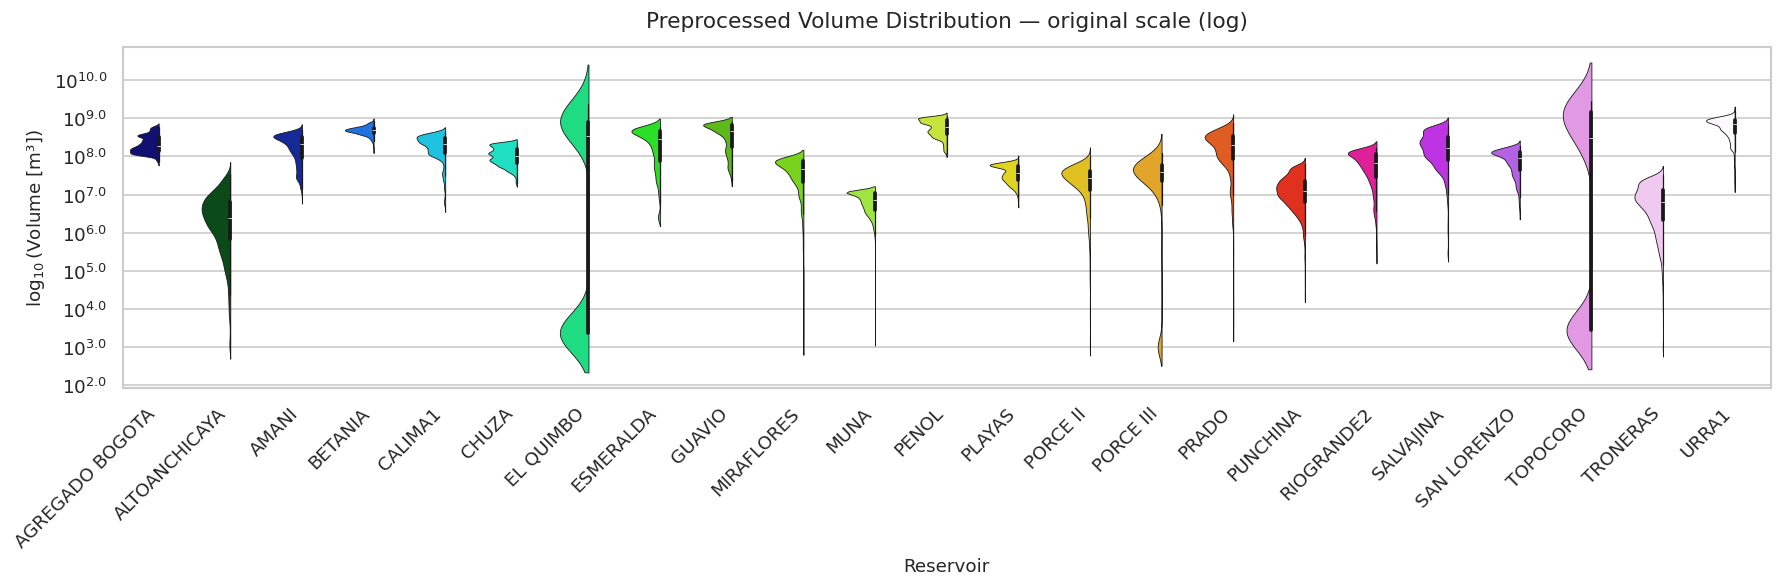

In [236]:
from matplotlib.collections import PolyCollection

x_min = scaler["x_min"]   # (1, D)
x_max = scaler["x_max"]   # (1, D)
V_all_orig = V_all_np * (x_max - x_min) + x_min   # (T_total, D), m³

df_orig = pd.DataFrame(V_all_orig, columns=reservoir_names)
df_orig_long = (
    df_orig
    .reset_index(drop=True)
    .melt(var_name="Reservoir", value_name="Volume_m3")
)
df_orig_long["log10_Volume"] = np.log10(np.maximum(1e3, df_orig_long["Volume_m3"]))

fig, ax = plt.subplots(figsize=(15, 5))
sns.violinplot(
    data=df_orig_long,
    x="Reservoir",
    y="log10_Volume",
    order=reservoir_names,
    palette=reservoir_color_dict,
    linewidth=0.5,
    ax=ax,
)

for collection in ax.collections:
    if isinstance(collection, PolyCollection):
        for path in collection.get_paths():
            verts = path.vertices
            center_x = (verts[:, 0].max() + verts[:, 0].min()) / 2
            verts[:, 0] = np.clip(verts[:, 0], -np.inf, center_x)

ax.set_title("Preprocessed Volume Distribution — original scale (log)", fontsize=13, pad=12)
ax.set_xlabel("Reservoir", fontsize=11)
ax.set_ylabel(r"$\log_{10}$(Volume [m³])", fontsize=11)
ax.yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda v, _: f"$10^{{{v:.1f}}}$")
)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


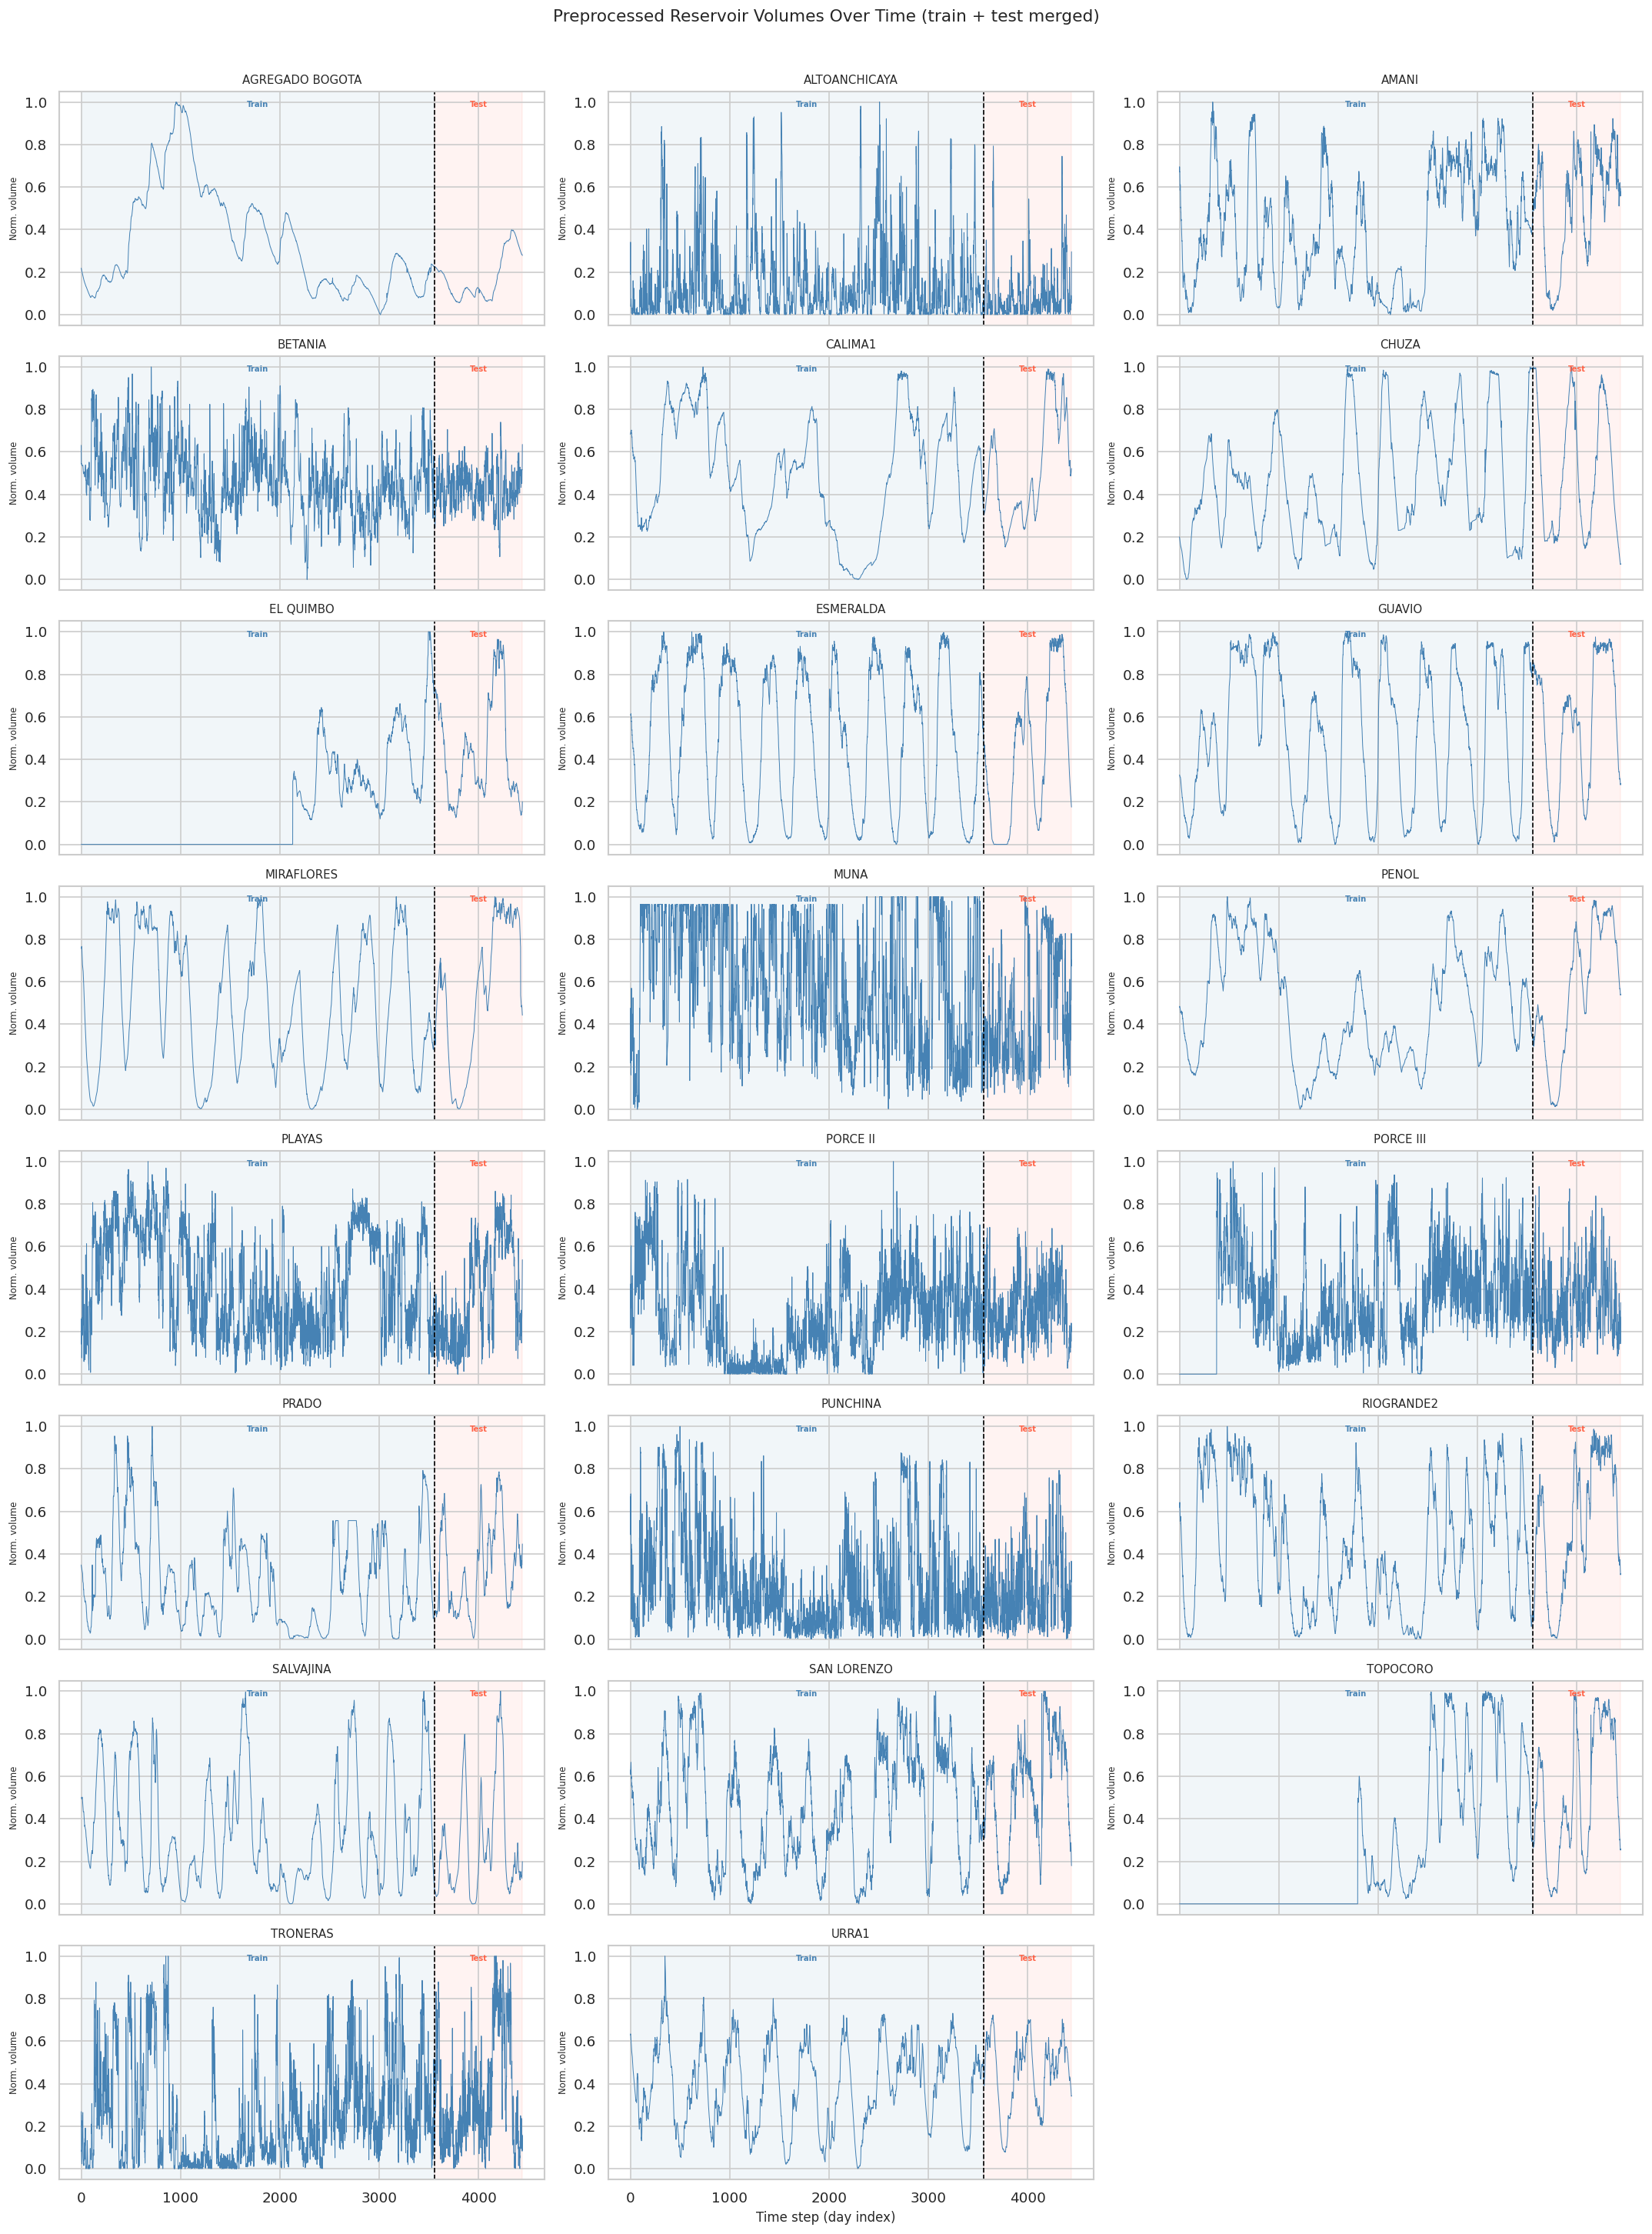

In [237]:
import math

N_COLS_p = 3
N_ROWS_p = math.ceil(D / N_COLS_p)
time_idx_all = np.arange(len(V_all_np))

fig, axes = plt.subplots(
    N_ROWS_p, N_COLS_p,
    figsize=(N_COLS_p * 6, N_ROWS_p * 3),
    sharex=True,
)
axes_flat = axes.flatten() if D > 1 else [axes]

for i, name in enumerate(reservoir_names):
    ax = axes_flat[i]

    # Single merged continuous line
    ax.plot(
        time_idx_all, V_all_np[:, i],
        color="steelblue", linewidth=0.6,
    )

    # Shaded backgrounds to distinguish train / test
    ax.axvspan(0,       N_TRAIN,          alpha=0.07, color="steelblue", zorder=0)
    ax.axvspan(N_TRAIN, len(V_all_np),    alpha=0.07, color="tomato",    zorder=0)

    # Split marker + labels
    ax.axvline(N_TRAIN, color="black", linewidth=1.0, linestyle="--")
    y_top = ax.get_ylim()[1]
    ax.text(N_TRAIN * 0.5,                y_top * 0.93, "Train", fontsize=6,
            ha="center", color="steelblue", fontweight="bold")
    ax.text(N_TRAIN + (len(V_all_np) - N_TRAIN) * 0.5, y_top * 0.93, "Test",
            fontsize=6, ha="center", color="tomato", fontweight="bold")

    ax.set_title(name, fontsize=9)
    ax.set_ylabel("Norm. volume", fontsize=7)
    ax.set_ylim(-0.05, 1.05)

for j in range(D, len(axes_flat)):
    axes_flat[j].set_visible(False)

fig.suptitle("Preprocessed Reservoir Volumes Over Time (train + test merged)", fontsize=13, y=1.01)
fig.supxlabel("Time step (day index)", fontsize=10)
plt.tight_layout()
plt.show()

## Optuna Hyperparameter Search

Loads the SQLite study and visualises:
- **Trials summary** — value and parameters per trial
- **Optimisation history** — NLPD objective over trials
- **Contour plots** — pairwise parameter interactions (M×Q, M×T, Q×T)


In [254]:
import optuna
import itertools
from optuna.visualization.matplotlib import (
    plot_optimization_history,
    plot_contour,
    plot_param_importances,
)

# OPTUNA_DB   = "outputs_gaussian/optuna/chdgamma_GaussianLMCLikelihood_H1.db"
OPTUNA_DB   = "outputs_gamma/optuna/chdgamma_ChainedGammaLikelihood_H1.db"
STUDY_NAME  = "chdgamma_ChainedGammaLikelihood_H1"


# STUDY_NAME  = "chdgamma_GaussianLMCLikelihood_H1"

optuna.logging.set_verbosity(optuna.logging.WARNING)
study = optuna.load_study(study_name=STUDY_NAME, storage=f"sqlite:///{OPTUNA_DB}")

In [250]:
# ── Merge root chdgamma_H1.db → outputs_gamma study ─────────────────────────
# The two studies used different distributions for M (Categorical vs Int).
# We repackage each source trial with the destination distributions so Optuna
# accepts it. The param *values* are preserved exactly.

from optuna.trial import FrozenTrial

SOURCE_DB   = "sqlite:///chdgamma_H1.db"
SOURCE_NAME = "chdgamma_H1"

src_study = optuna.load_study(study_name=SOURCE_NAME, storage=SOURCE_DB)
complete_src = [
    t for t in src_study.trials
    if t.state == optuna.trial.TrialState.COMPLETE
]

# Canonical distributions from an existing destination trial
dst_distributions = next(
    t.distributions
    for t in study.trials
    if t.state == optuna.trial.TrialState.COMPLETE
)

added = 0
for t in complete_src:
    new_trial = FrozenTrial(
        number=t.number,
        trial_id=t._trial_id,
        state=t.state,
        value=t.value,          # single-objective: use value, not values
        datetime_start=t.datetime_start,
        datetime_complete=t.datetime_complete,
        params=t.params,
        distributions=dst_distributions,
        user_attrs=t.user_attrs,
        system_attrs=t.system_attrs,
        intermediate_values=t.intermediate_values,
    )
    study.add_trial(new_trial)
    added += 1

# Reload to refresh internal state
study = optuna.load_study(study_name=STUDY_NAME, storage=f"sqlite:///{OPTUNA_DB}")

print(f"Merged {added} COMPLETE trial(s) from '{SOURCE_NAME}'.")
print(f"Total COMPLETE trials in '{STUDY_NAME}' now: "
      f"{sum(1 for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE)}")


Merged 9 COMPLETE trial(s) from 'chdgamma_H1'.
Total COMPLETE trials in 'chdgamma_ChainedGammaLikelihood_H1' now: 84


## Trials summary table

In [276]:
df_trials = study.trials_dataframe(attrs=("number", "value", "params", "state"))
df_trials = df_trials.rename(columns={"value": "NLPD (val)"})


display(
    df_trials.style
    .format({"NLPD (val)": "{:.4f}"})
    .highlight_min(subset=["NLPD (val)"], color="#13411c")
    .set_caption(f"Optuna trials — best: {study.best_value:.4f}  @ {study.best_params}")
)


,number,NLPD (val),params_M,params_Q,params_T,state
0,0,-14.0010,128,32,7,COMPLETE
1,1,-13.4328,168,24,30,COMPLETE
2,2,-11.3543,196,16,14,COMPLETE
3,3,-13.9176,174,36,7,COMPLETE
4,4,-9.4445,194,10,2,COMPLETE
5,5,-12.7343,152,22,21,COMPLETE
6,6,-12.9396,146,22,21,COMPLETE
7,7,-12.7175,144,22,21,COMPLETE
8,8,-13.1253,128,24,21,COMPLETE
9,9,-13.1466,128,24,21,COMPLETE


In [253]:
# ── Overwrite DB: keep only COMPLETE trials ───────────────────────────────────
complete_trials = [
    t for t in study.trials
    if t.state == optuna.trial.TrialState.COMPLETE
]
n_removed = len(study.trials) - len(complete_trials)

# Delete the study entirely from the DB, then recreate with the same name/direction
storage_url = f"sqlite:///{OPTUNA_DB}"
optuna.delete_study(study_name=STUDY_NAME, storage=storage_url)
study = optuna.create_study(
    study_name=STUDY_NAME,
    storage=storage_url,
    direction="minimize",
)

# Re-add only the complete trials (numbers are reassigned 0, 1, 2, …)
for t in complete_trials:
    study.add_trial(t)

print(f"Removed        : {n_removed}  (FAIL + PRUNED)")
print(f"Kept (COMPLETE): {len(study.trials)}")

# Refresh df_trials from the clean study
df_trials = study.trials_dataframe(attrs=("number", "value", "params", "state"))
df_trials = df_trials.rename(columns={"value": "NLPD (val)"})



Removed        : 0  (FAIL + PRUNED)
Kept (COMPLETE): 84


## Opt history

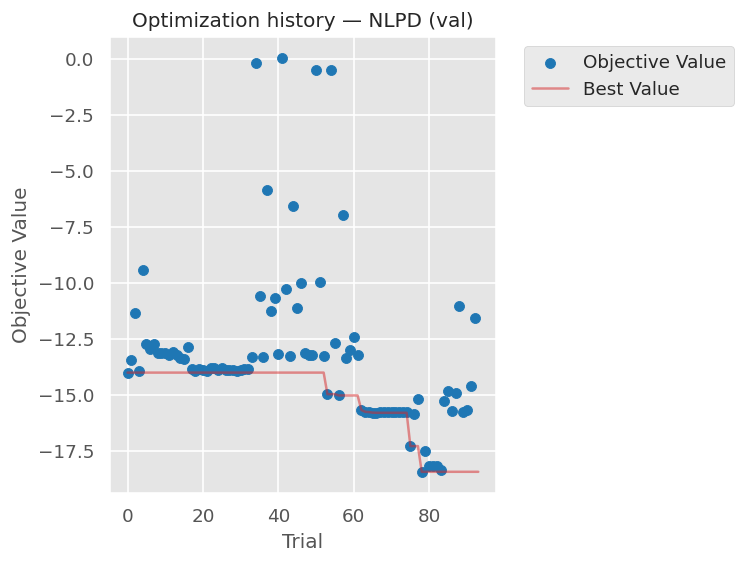

In [277]:
ax_hist = plot_optimization_history(study)
ax_hist.set_title("Optimization history — NLPD (val)", fontsize=12)
ax_hist.figure.tight_layout()
plt.show()


## Param relevance

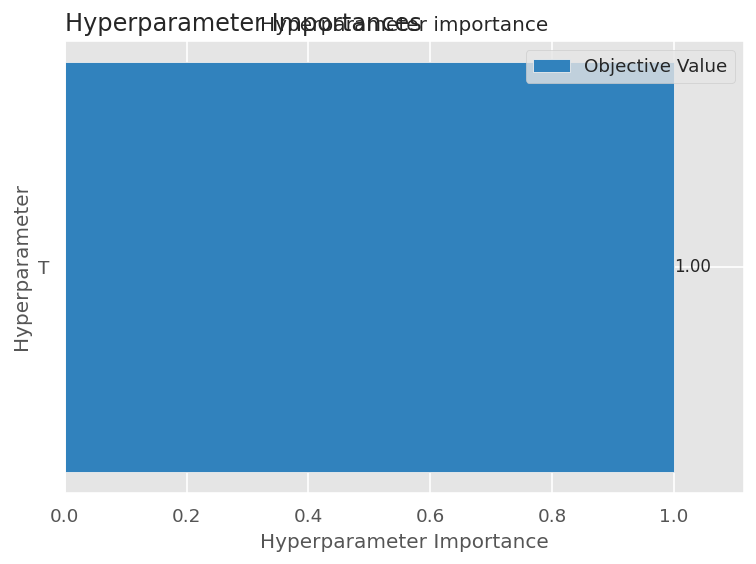

In [278]:
ax_imp = plot_param_importances(study)
ax_imp.set_title("Hyperparameter importance", fontsize=12)
ax_imp.figure.tight_layout()
plt.show()

## Contour Plots

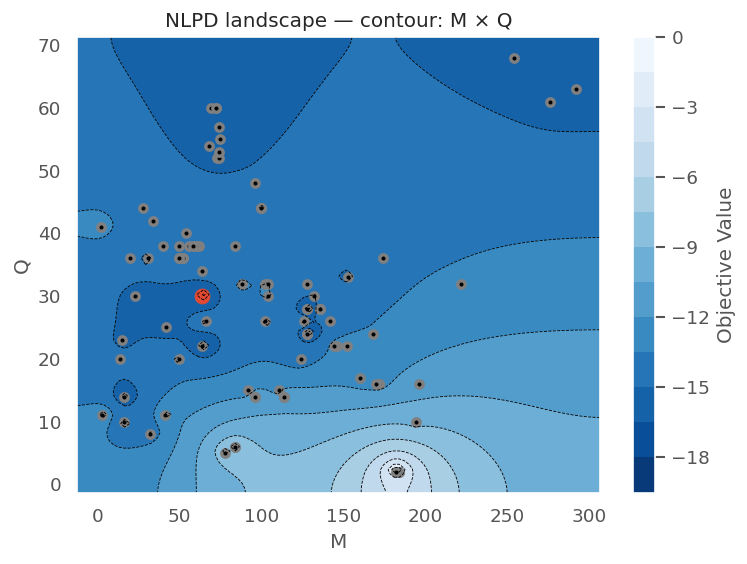

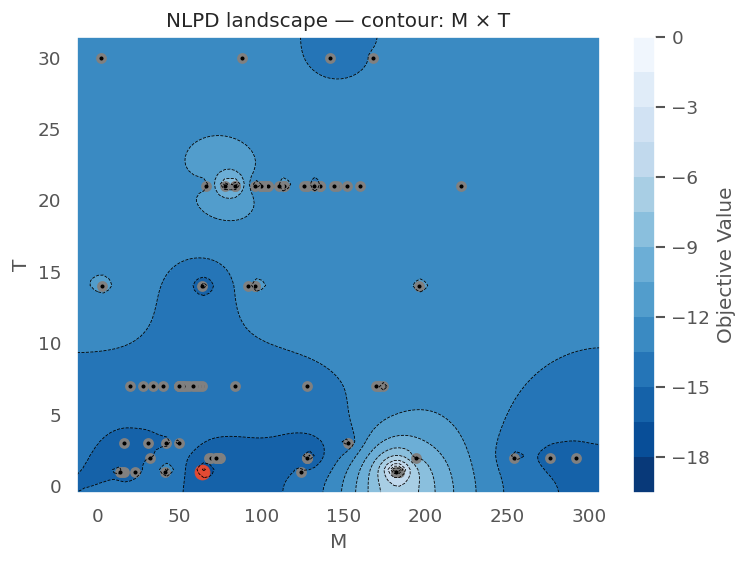

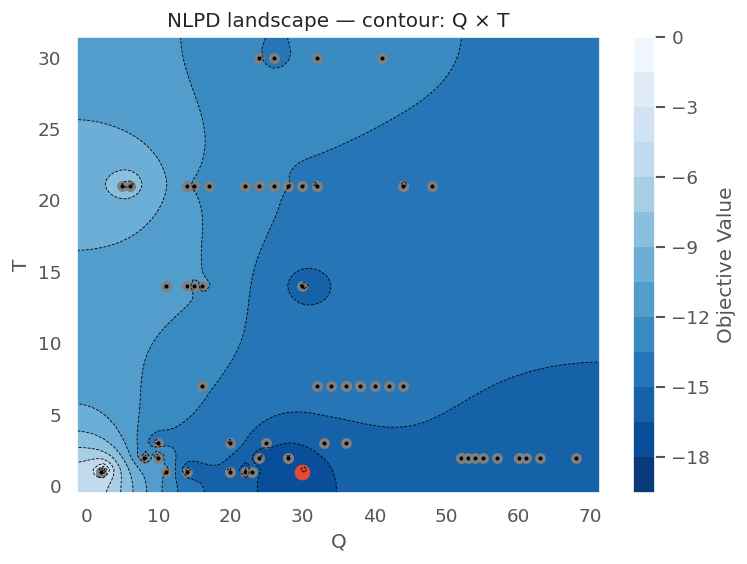

In [279]:
param_names = list(study.best_params.keys())   # ['M', 'Q', 'T']
pairs = list(itertools.combinations(param_names, 2))


best = study.best_params

for px, py in pairs:
    ax_c = plot_contour(study, params=[px, py])

    x_best = best[px]
    y_best = best[py]

    # Optional: also mark center
    ax_c.scatter(x_best, y_best, s=80)

    ax_c.set_title(f"NLPD landscape — contour: {px} × {py}", fontsize=12)
    ax_c.figure.tight_layout()

    plt.show()